In [2]:
from setup import channel
import numpy as np
import matplotlib.pyplot as plt

from mpi4py import MPI
from petsc4py import PETSc

import numpy as np
import ufl
from dolfinx.fem import Function, functionspace, locate_dofs_geometrical, dirichletbc
from dolfinx.mesh import create_rectangle, CellType

import msgfem_parallel as msgfem
import helper
import preconditioner as pre
import setup
from dolfinx import geometry


2025-10-23 15:56:59,979	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [15]:
def eval_fem_solution(X, uh, domain):
    """
    Evaluates the solution uh of the variational problem at new points x of shape (3, num_points). Only basis functions that belong 
    to cells the new points belong are evaluated.

    Arguments:
    ---------
        X (np.array): new input coordinates of shape (3, num_points).
        uh (Coefficient): FeniCS solution to variational formulation.
        domain (dolfinx.mesh.Mesh): Finite element mesh.

    Returns:
    --------
        u_values (np.array): array of values uh(X)  of shape (uh_dim, num_points).
    """

    bb_tree = geometry.bb_tree(domain, domain.topology.dim)
    cells = []
    points_on_proc = []
    # Find cells whose bounding-box collide with the the points
    cell_candidates = geometry.compute_collisions_points(bb_tree, X.T)
    # Choose one of the cells that contains the point
    colliding_cells = geometry.compute_colliding_cells(domain, cell_candidates, X.T)
    for i, point in enumerate(X.T):
        if len(colliding_cells.links(i)) > 0:
            points_on_proc.append(point)
            cells.append(colliding_cells.links(i)[0])

    points_on_proc = np.array(points_on_proc)
    u_values = uh.eval(points_on_proc, cells)
    
    return u_values.T

### check vs ca code on subdomain 5 

In [16]:
coeff_A = np.load("data_FNO/coeff_A_5.npy")
print(coeff_A.shape)
phi = np.load("data_FNO/phi_5.npy")
print(phi.shape)
eig_vals = np.load("data_FNO/eig_vals_dom_5.npy")
print(eig_vals.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data_FNO/coeff_A_5.npy'

In [ ]:
coeff_A = np.load("data_FNO/coeff_A_sub_dom_5_sample_0.npy")


FileNotFoundError: [Errno 2] No such file or directory: 'data_FNO/coeff_A_sub_dom_5_sample_0.npy'

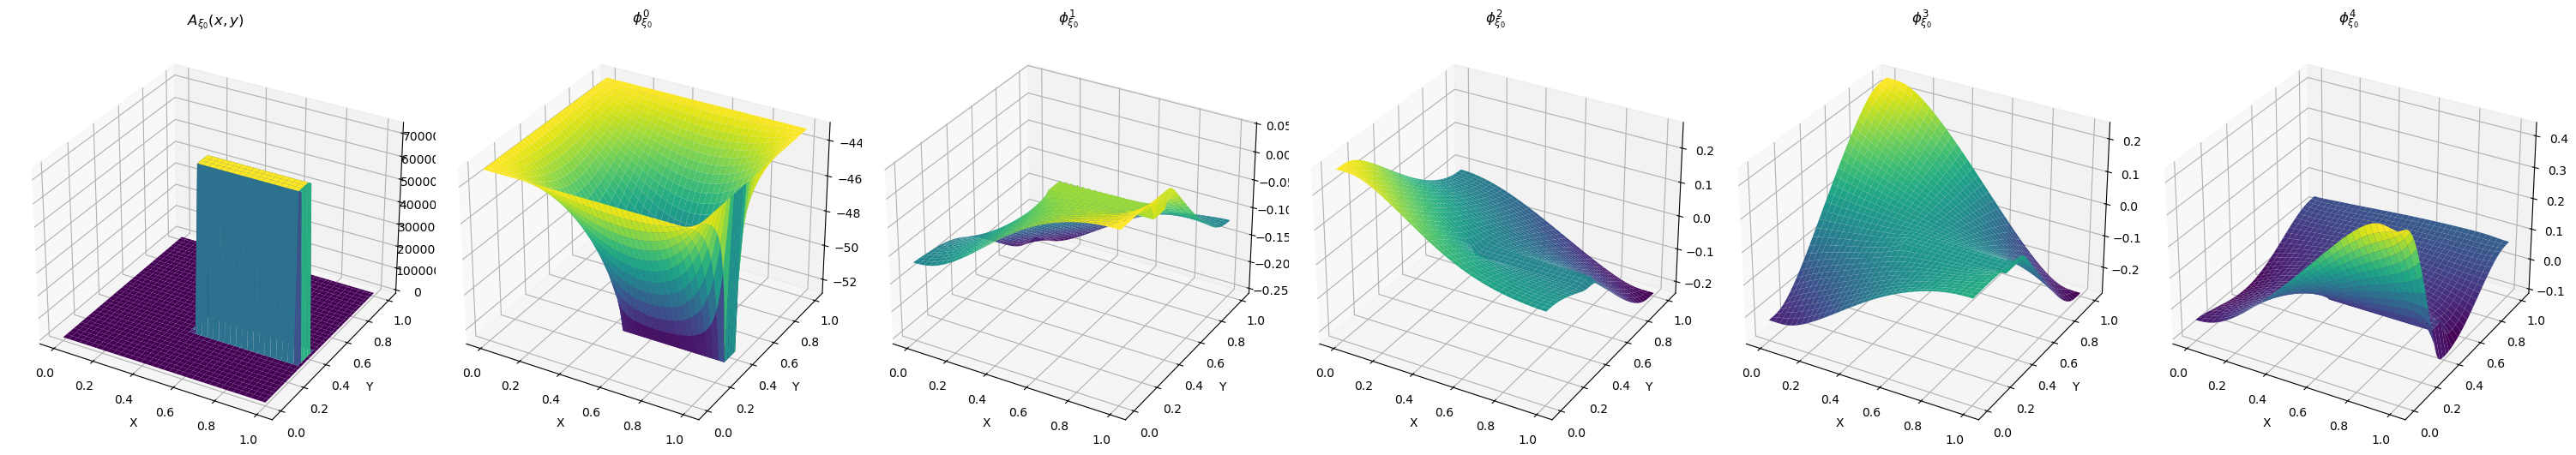

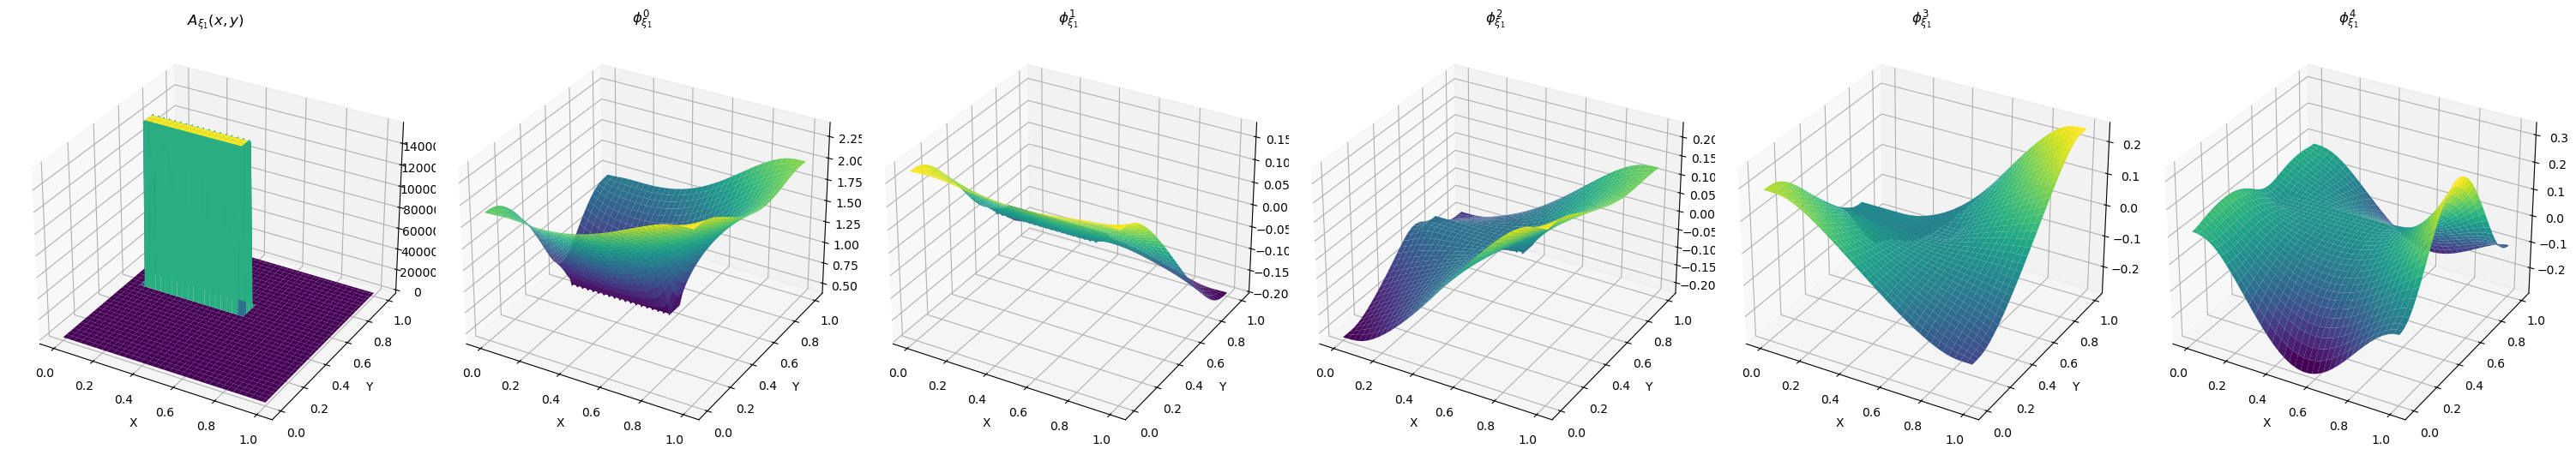

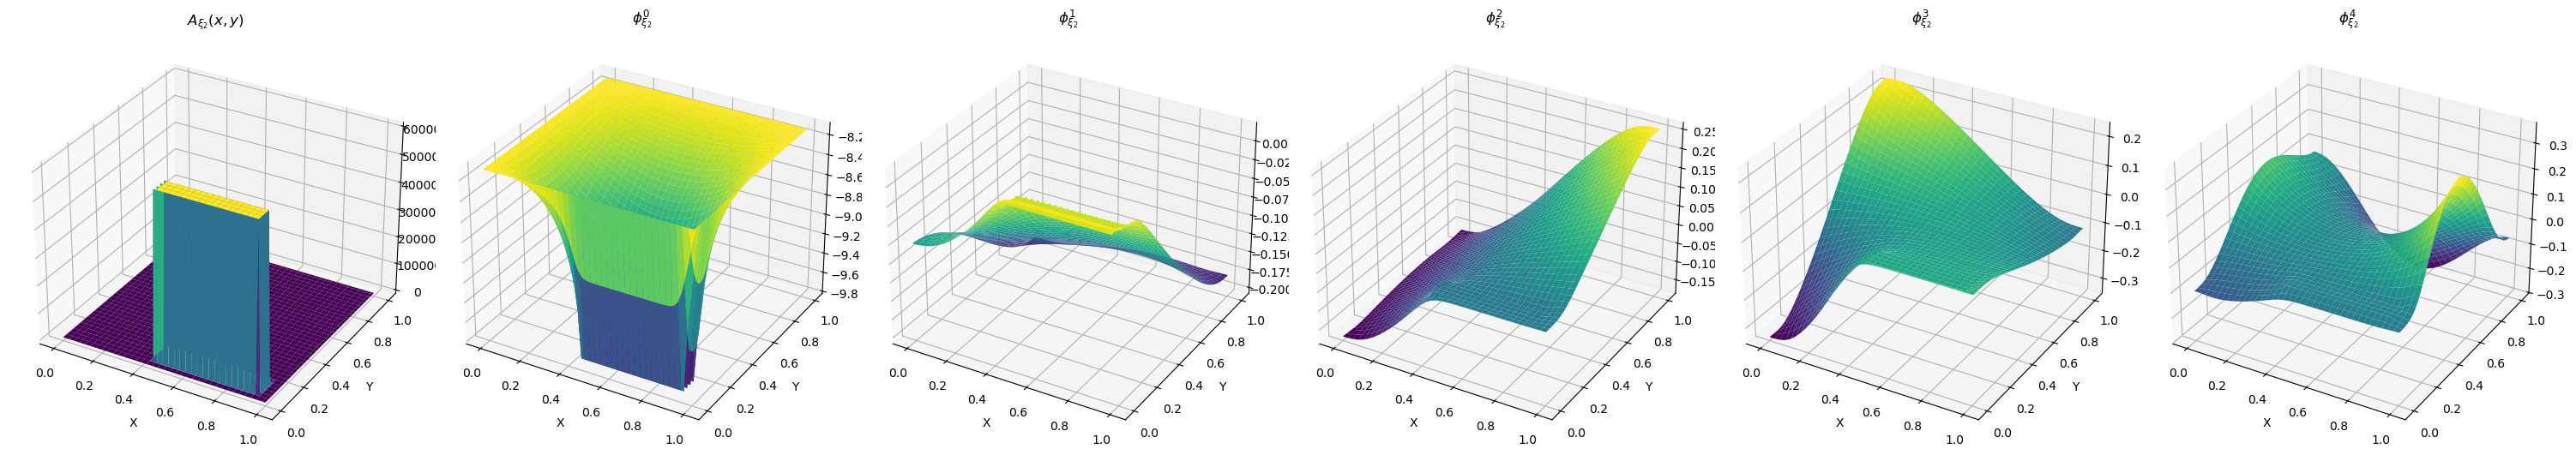

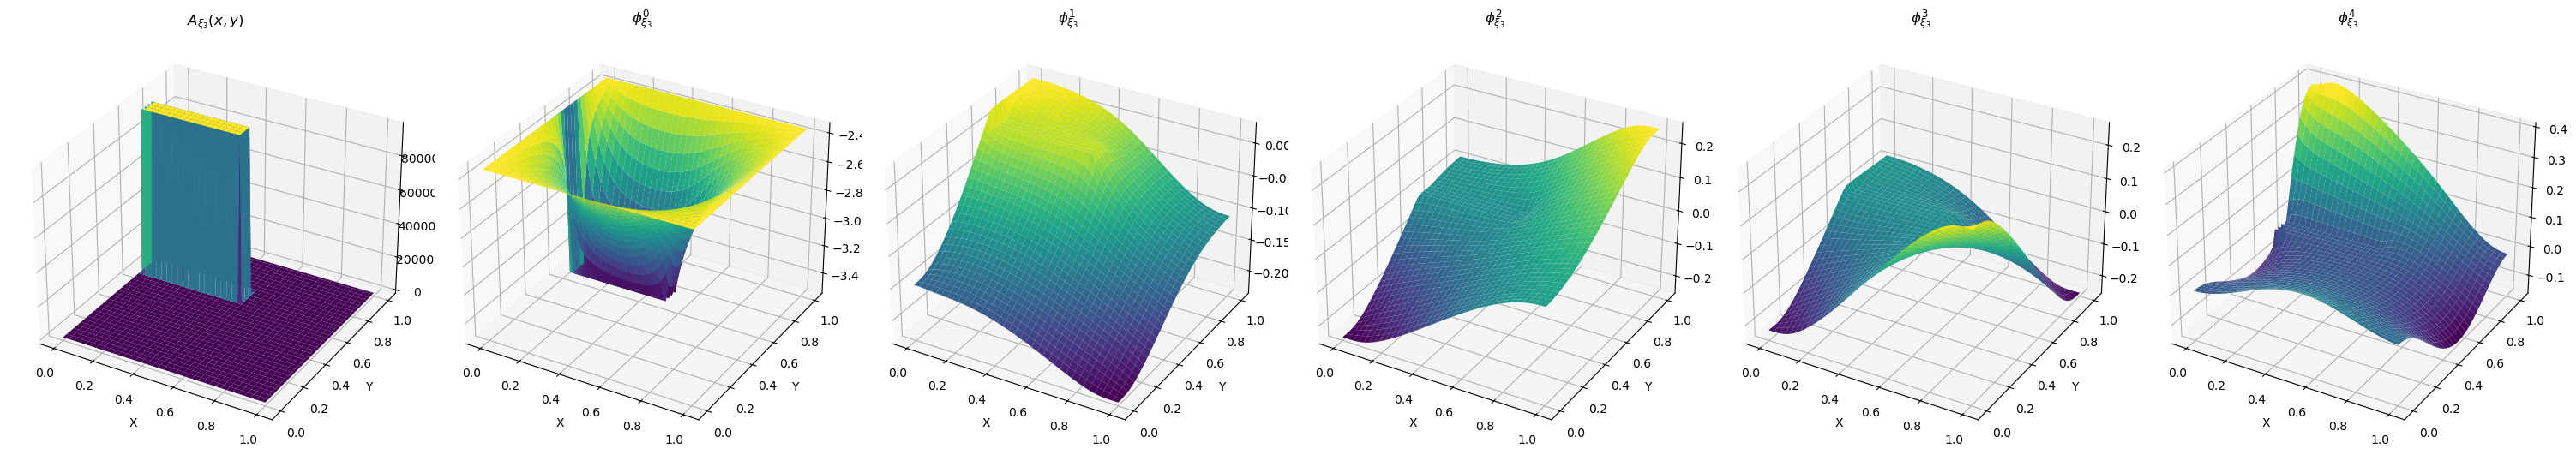

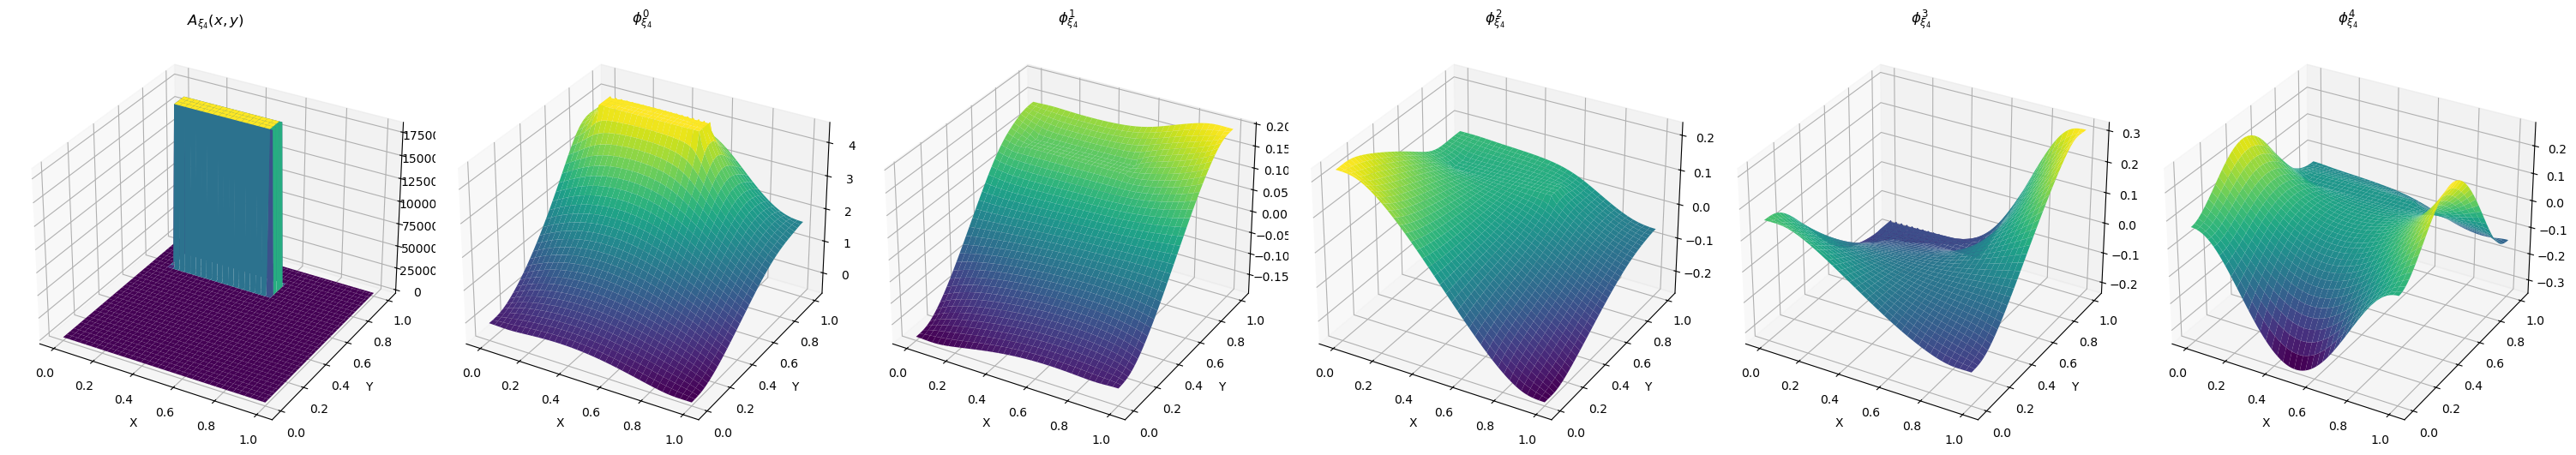

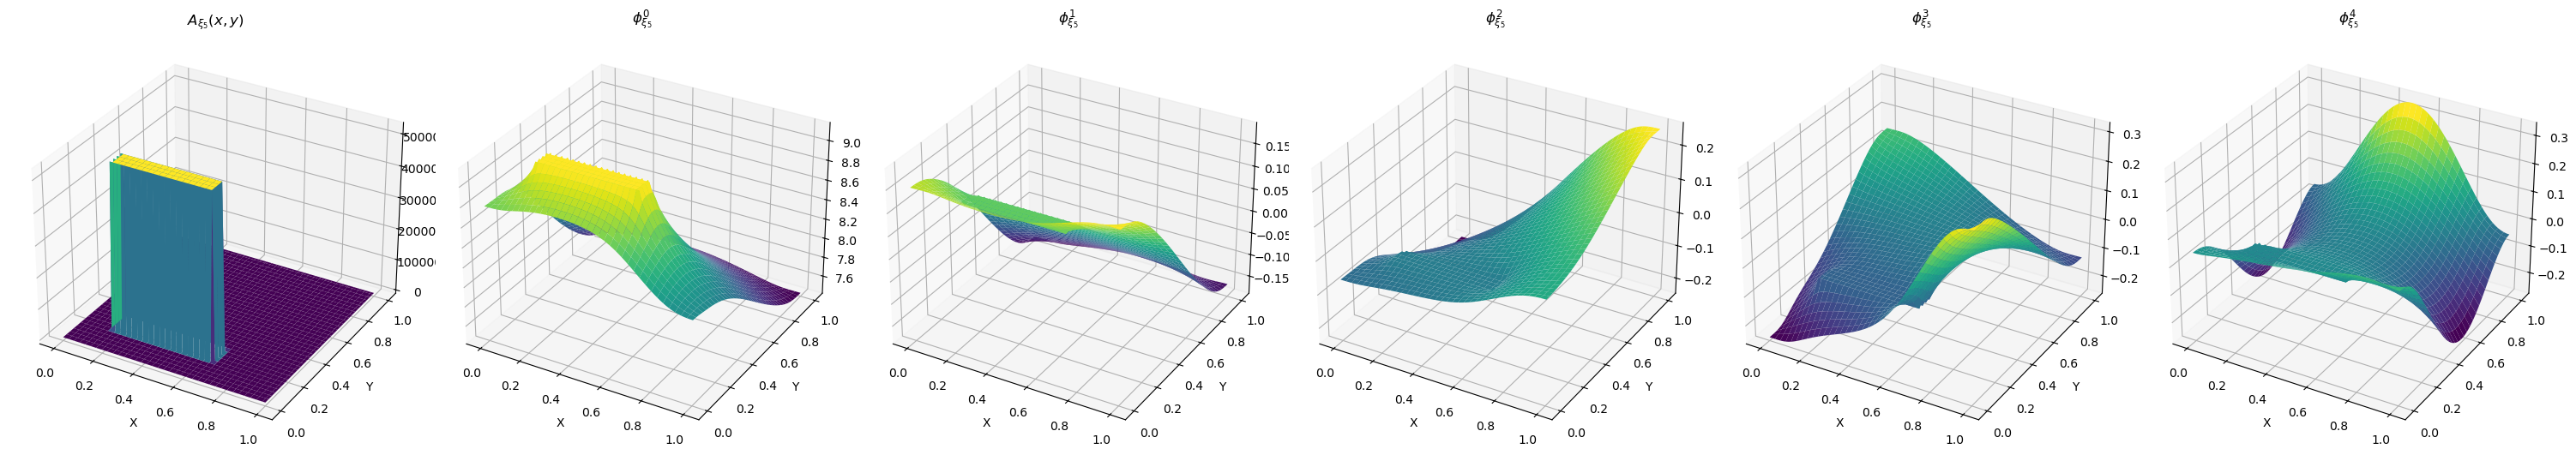

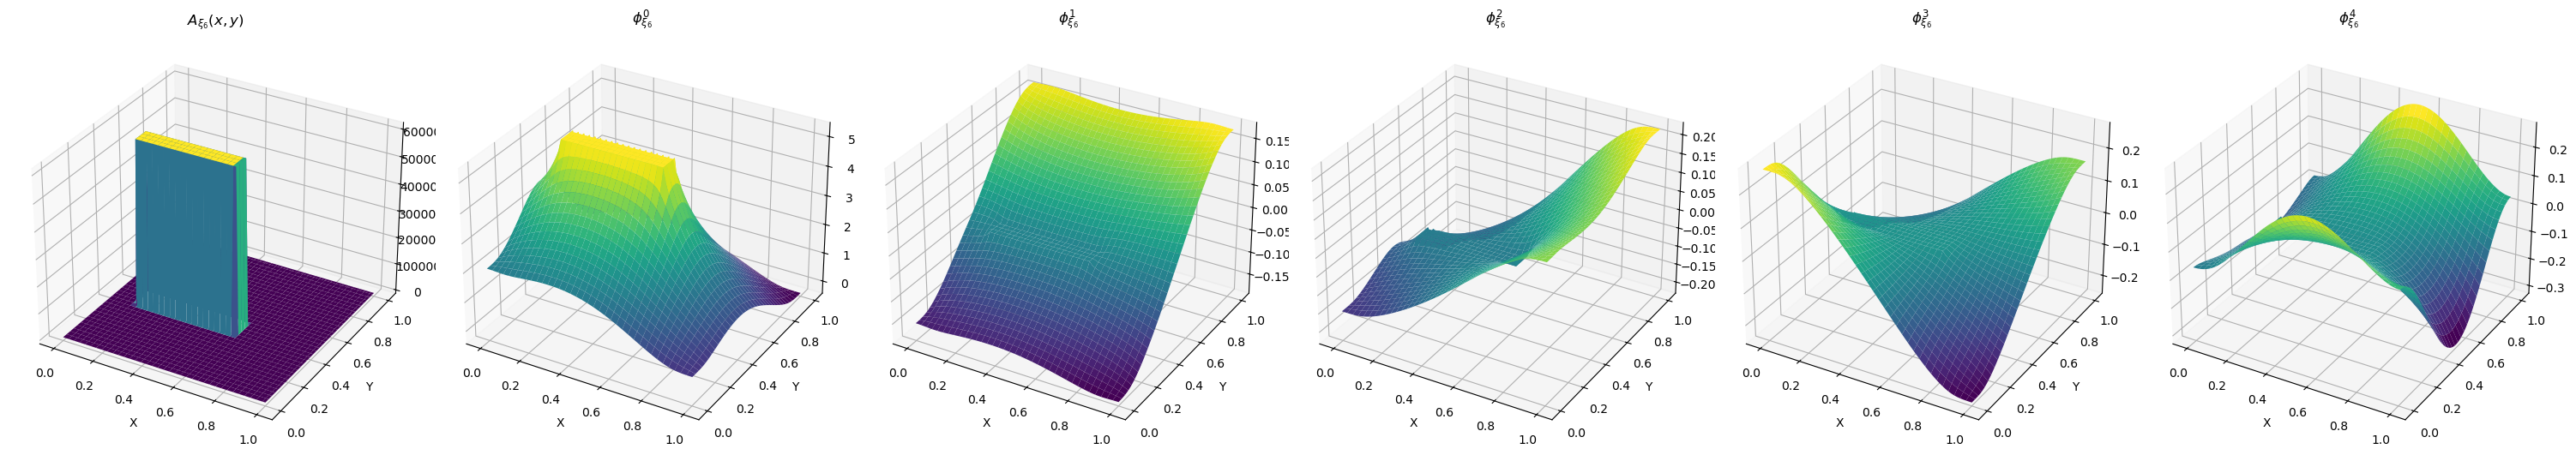

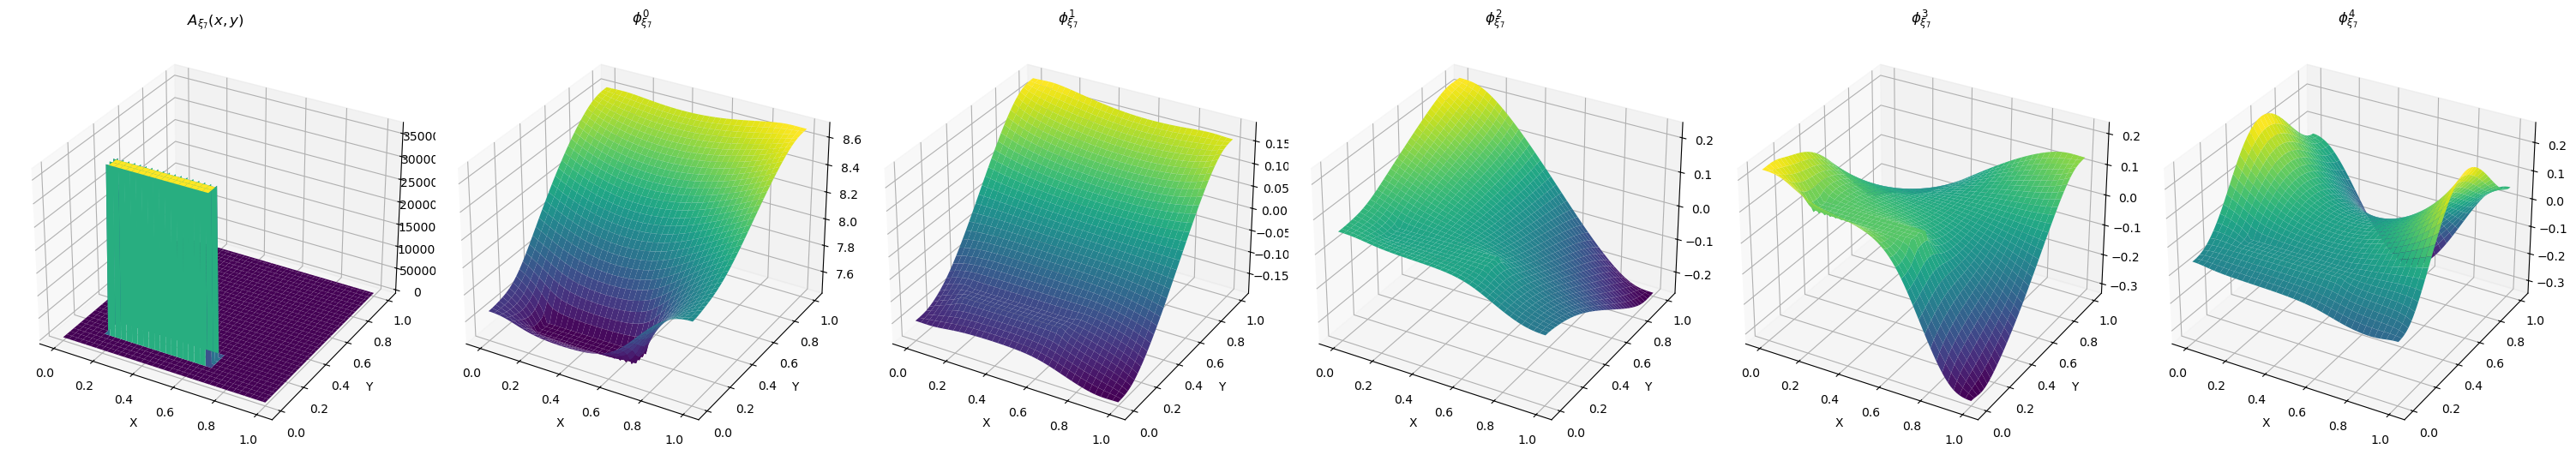

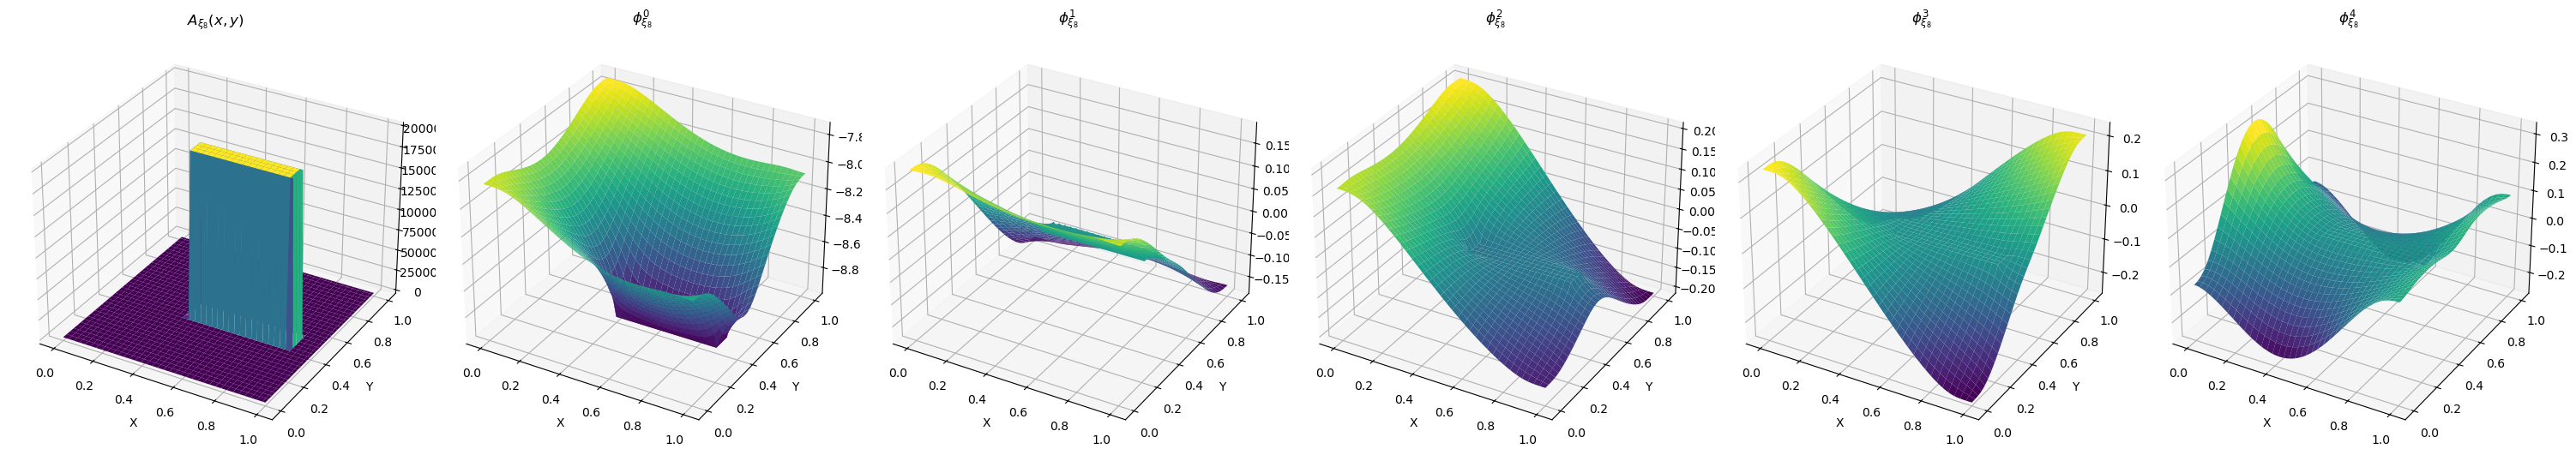

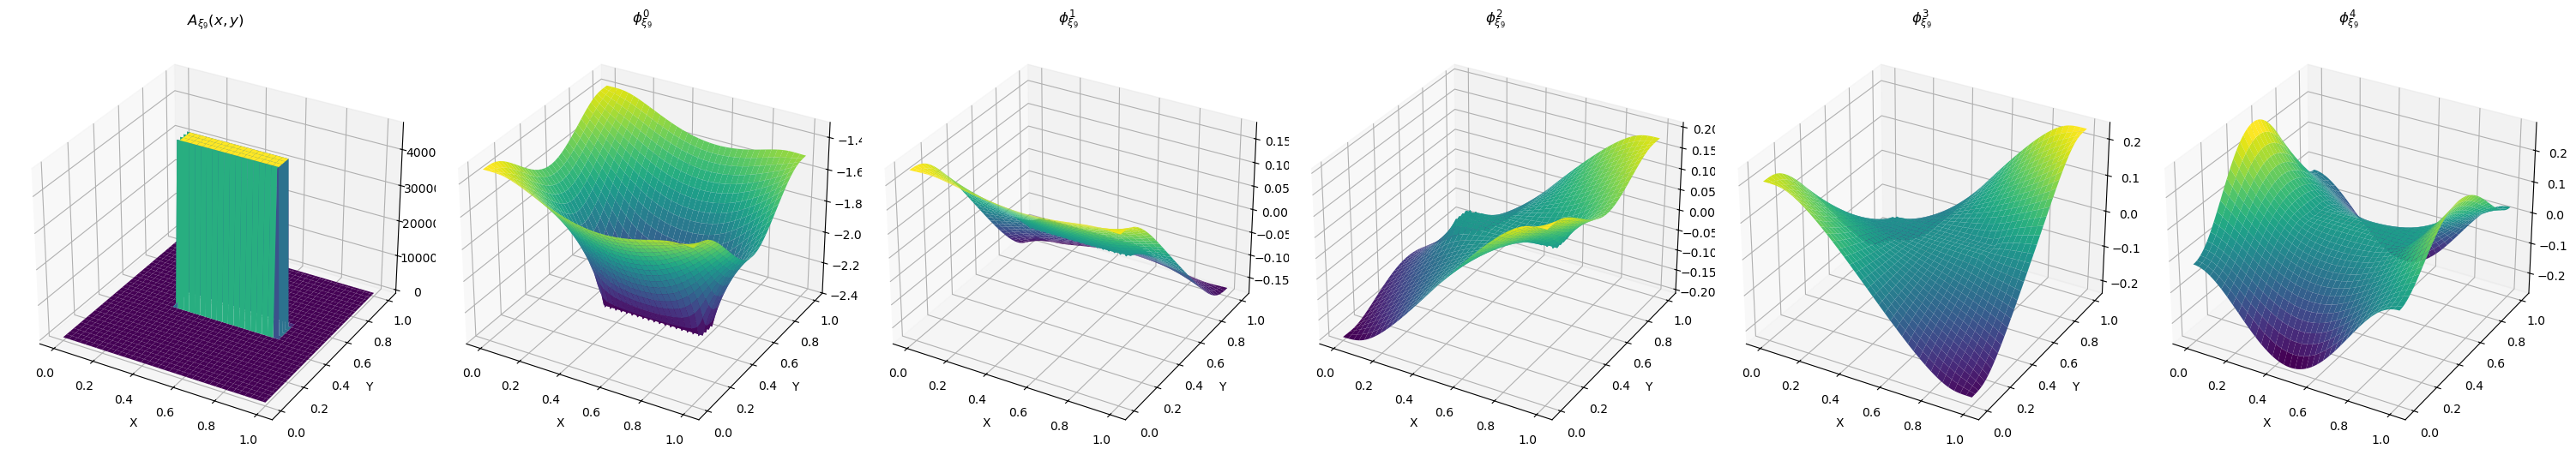

In [46]:
num_samples = 10

for s in range(num_samples):
    coeff_A = np.load("data_FNO/coeff_A_sub_dom_5_sample_%s.npy"%s)
    phi = np.load("data_FNO/phi_sub_dom_5_sample_%s.npy"%s)
    n_loc = phi.shape[2]
    fig, axes = plt.subplots(1, n_loc+1, figsize=(30, 20), subplot_kw={'projection': '3d'})
    xs = np.linspace(0, 1, coeff_A.shape[0])
    X, Y = np.meshgrid(xs, xs)
    Z = coeff_A
    surf = axes[0].plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=True)
    axes[0].set_title(r'$A_{\xi_%s}(x,y)$'%s)
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y'); axes[0].set_zlabel('Z')
    #fig.colorbar(surf, ax=axes[0], shrink=0.6, aspect=10)

    for i in range(n_loc):
        xs = np.linspace(0, 1, phi.shape[0])
        X, Y = np.meshgrid(xs, xs)
        Z = phi[:,:,i]
        surf = axes[i+1].plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=True)
        axes[i+1].set_title(r'$\phi_{\xi_%s}^{%s}$'%(s,i))
        axes[i+1].set_xlabel('X'); axes[i].set_ylabel('Y'); axes[i].set_zlabel('Z')
        #fig.colorbar(surf, ax=axes[i], shrink=0.6, aspect=10)
    
    plt.tight_layout()
    fig.savefig("plots/samples/coeff_A_and_basis_funcs_sub_dom_5_sample_%s.svg"%s)
    plt.show()

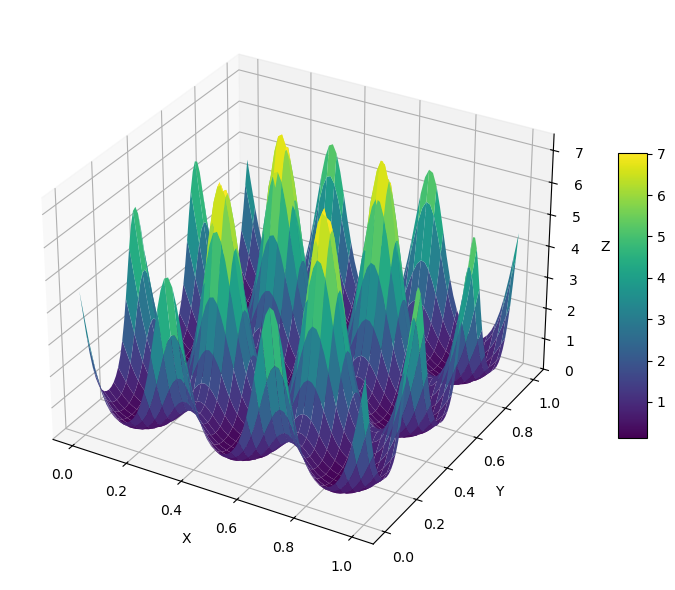

In [ ]:
xs = np.linspace(0, 1, coeff_A.shape[0])

fig = plt.figure(figsize=(8, 6))
X, Y = np.meshgrid(xs, xs, indexing='xy')
Z = coeff_A
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()

In [45]:
np.random.uniform(low = [1,20,30], high = [4,50,60], size=(10,3))

array([[ 2.61734525, 25.74775967, 38.79546692],
       [ 2.70240188, 38.41439777, 45.22468756],
       [ 1.04342026, 34.30086116, 48.38527978],
       [ 1.57744922, 28.85459654, 48.04366656],
       [ 1.07786748, 30.43869335, 43.99311176],
       [ 2.89459091, 31.98616324, 39.40190108],
       [ 2.24715658, 43.53000228, 59.01998824],
       [ 3.24240876, 39.72561474, 57.52281005],
       [ 3.16041099, 27.98217077, 57.24403991],
       [ 1.88447272, 26.06995265, 40.5007095 ]])

In [ ]:
xs = np.linspace(0.234375, 0.515625, 1000)
X = np.meshgrid(xs, xs, indexing='ij')
x0 = 0.234375
y1 = 0.515625
p0 = np.random.uniform(low=0.0, high=9/10*(y1-x0))
p1 = np.random.uniform(low=0.0, high=1/2*(y1-x0))
Z = setup.channel_sub_dom_five(X, [p0, p1,20])

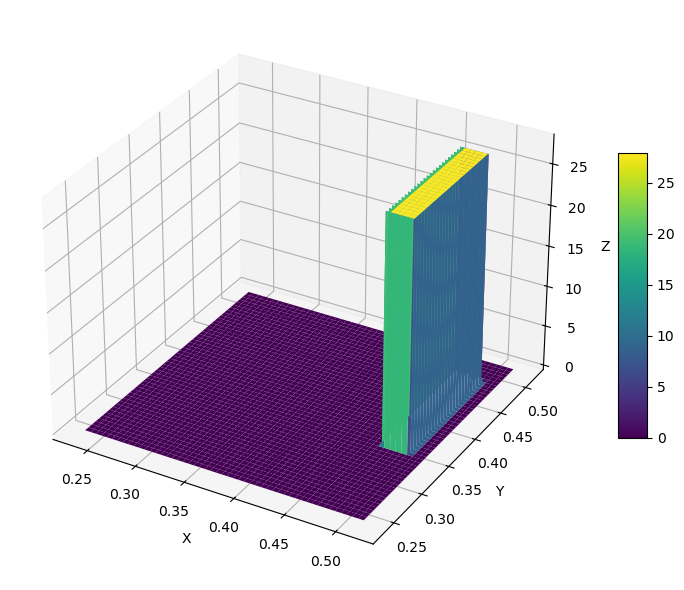

In [43]:
xs = np.linspace(0.234375, 0.515625, 1000)
X = np.meshgrid(xs, xs, indexing='ij')
x0 = 0.234375
y1 = 0.515625
p0 = np.random.uniform(low=0.0, high=9/10*(y1-x0))
p1 = np.random.uniform(low=0.0, high=1/2*(y1-x0))
p2 = np.random.uniform(low=20, high= 50)
Z = setup.channel_sub_dom_five(X, [p0, p1,p2])
fig = plt.figure(figsize=(8, 6))
X, Y = np.meshgrid(xs, xs, indexing='ij')
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()

In [ ]:
coeff_A = np.load("data_FNO/phi_sub_dom_5_sample_%s.npy"%0)
torch.permute(torch.tensor(np.load("data_FNO/phi_sub_dom_5_sample_%s.npy"%0), dtype=torch.float32), (2,0,1)).shape

(73, 73, 5)

In [ ]:
num_samples = 12
nx = 72
ny = 72

nxphi = 73
nyphi = 73
coeff_A_tensor = torch.zeros((num_samples,1, ny, ny))
phi_tensor = torch.zeros((num_samples, n_loc, nxphi, nyphi))

for s in range(num_samples):
    coeff_A = torch.tensor(np.load("data_FNO/coeff_A_sub_dom_5_sample_%s.npy"%s), dtype=torch.float32)
    phi = np.load("data_FNO/phi_sub_dom_5_sample_%s.npy"%s)
    
    coeff_A_tensor[s,0,:,:] = coeff_A
    phi[s,:,:,:] = torch.permute(torch.tensor(phi, dtype=torch.float32), (2,0,1))

    